<a href="https://colab.research.google.com/github/MahanSinghRajput/ANN/blob/main/ANN_CA2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
df = pd.read_csv("hostel_dataset.csv")

print(df.head()) #shows first 5 rows
print(df.shape) #no. of rows and columns

   Price  Distance_km  Room_Capacity  Wifi  Mess  Security_Rating  AC  \
0  10270         2.85              1     1     1                4   0   
1   3860         1.98              2     0     1                4   0   
2   8390         4.86              1     1     1                7   0   
3   8191         4.26              4     1     1                9   0   
4   8734         3.64              2     1     0                6   0   

   Attached_Washroom  Vending_Machine  Study_Room  Gym  Lift Hostel_Type  
0                  1                0           1    1     0     Premium  
1                  1                1           1    0     0      Budget  
2                  0                1           1    0     0     Premium  
3                  0                0           0    0     1     Premium  
4                  0                1           0    0     0     Premium  
(100, 13)


In [3]:
#Exploratory Data Analysis(EDA)
print(df.info())
print(df.isnull().sum())
print(df['Hostel_Type'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Price              100 non-null    int64  
 1   Distance_km        100 non-null    float64
 2   Room_Capacity      100 non-null    int64  
 3   Wifi               100 non-null    int64  
 4   Mess               100 non-null    int64  
 5   Security_Rating    100 non-null    int64  
 6   AC                 100 non-null    int64  
 7   Attached_Washroom  100 non-null    int64  
 8   Vending_Machine    100 non-null    int64  
 9   Study_Room         100 non-null    int64  
 10  Gym                100 non-null    int64  
 11  Lift               100 non-null    int64  
 12  Hostel_Type        100 non-null    object 
dtypes: float64(1), int64(11), object(1)
memory usage: 10.3+ KB
None
Price                0
Distance_km          0
Room_Capacity        0
Wifi                 0
Mess           

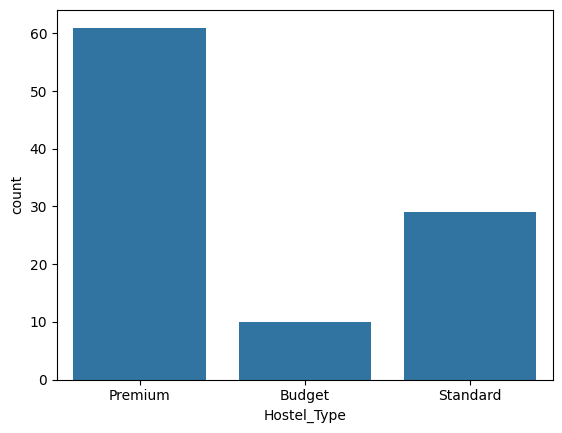

In [4]:
#Graphs
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x = 'Hostel_Type', data = df)
plt.show()

In [8]:
#Data Preprocessing
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Hostel_Type'] = le.fit_transform(df['Hostel_Type'])

#Feature Selection
X = df.drop('Hostel_Type', axis = 1)
y = df['Hostel_Type']

#Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [9]:
#Train KNN Model
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

In [11]:
#Train SVM model
from sklearn.svm import SVC
svm = SVC()
svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

In [12]:
#Evaluating Models
from sklearn.metrics import accuracy_score

print("KNN Accuracy:", accuracy_score(y_test, knn_pred))
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

KNN Accuracy: 0.75
SVM Accuracy: 0.75


In [13]:
#K-Fold Validation
from sklearn.model_selection import cross_val_score
scores = cross_val_score(knn, X, y, cv = 5)
print("KNN Cross Validation Score:", scores.mean())

KNN Cross Validation Score: 0.8700000000000001
